In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

In [2]:
resc_raw = pd.read_csv('구급 현황_2023_전국.csv')
# resc_raw

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_16200\2026129618.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  resc_raw = pd.read_csv('구급 현황_2023_전국.csv')


In [3]:
resc_col = pd.read_excel('소방청_전국 구급 현황_컬럼 정보 데이터.xlsx', header=1)
resc_col = resc_col[['컬럼 영문명', '컬럼 한글명']].set_index('컬럼 영문명')
resc_col.index = resc_col.index.str.upper()
resc_col = resc_col['컬럼 한글명']
resc_col

c:\Users\Win11Pro\anaconda3\envs\PY_10\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


컬럼 영문명
GRNDS2_DSTNC          2현장거리
GRNDS3_DSTNC          3현장거리
SEASN_NM                계절명
TRFC_ACDNT_SE_NM    교통사고구분명
RLF_RPTP_NO         구급보고서번호
                     ...   
PTN_CNTC_MM           환자접촉월
PTN_CNTC_DAY          환자접촉일
PTN_CNTC_YMD         환자접촉일자
PTN_SYM_SE_NM       환자증상구분명
PTN_CR_NM             환자직업명
Name: 컬럼 한글명, Length: 71, dtype: object

In [4]:
resc = resc_raw.rename(resc_col, axis=1)
# resc

In [5]:
resc.columns

Index(['구급보고서번호', '등록완료구분명', '환자발생유형명', '환자증상구분명', '중증외상명', '심정지명',
       '심혈관뇌혈관구분명', '교통사고구분명', '기타교통사고명', '동물기타분류명', '기타발생유형명', '소방서명', '센터명',
       '구급활동구분명', '헬기펌뷸런스유무명', '신고일자', '신고시각', '신고연도', '계절명', '분기번호', '신고월',
       '신고일', '신고시간', '신고분', '신고요일', '출동일자', '출동시각&nbsp;', '출동연도', '출동월',
       '출동일', '출동시간', '출동분', '현장도착일자', '현장도착시각', '현장도착연도', '현장도착월', '현장도착일',
       '현장도착시간', '현장도착분', '환자접촉일자', '환자접촉시각', '환자접촉연도', '환자접촉월', '환자접촉일',
       '환자접촉시간', '환자접촉분', '현장거리', '현장출발일자', '현장출발시각', '현장출발연도', '현장출발월',
       '현장출발일', '현장출발시간', '현장출발분', '복귀일자', '복귀시각', '복귀연도', '복귀월', '복귀일',
       '복귀시간', '복귀분', '종결구분명', '성별명', '환자시도명', '시도명', '시군구명', '도시농촌구분명',
       '환자직업명', '2현장거리', '3현장거리', '이송분류명'],
      dtype='object')

In [6]:
resc.columns[resc.isna().sum()>len(resc)/2]

Index(['중증외상명', '심정지명', '심혈관뇌혈관구분명', '교통사고구분명', '기타교통사고명', '동물기타분류명',
       '기타발생유형명', '헬기펌뷸런스유무명', '복귀일자', '복귀연도', '복귀월', '복귀일', '복귀시간', '복귀분',
       '3현장거리'],
      dtype='object')

In [7]:
resc['교통사고구분명'].value_counts()

교통사고구분명
운전자       52826
오토바이사고    37624
동승자       31708
보행자       30507
자전거사고     23483
기타탈것      11680
미상          712
Name: count, dtype: int64

In [8]:
# 연습문제
x = [10,20,5,40,6]
k = []
for v in x:
    v2 = 'a' if v > 10 else 'b'
    k.append(v2)
print(k)

k = ['a' if i > 10 else 'b' for i in x]
print(k)

['b', 'a', 'b', 'a', 'b']
['b', 'a', 'b', 'a', 'b']


In [9]:
# 연습 문제 list comprehension
x = [3,4,6,7,8]
k = ['홀' if i % 2 == 1 else '짝' for i in x]
k

['홀', '짝', '짝', '홀', '짝']

In [10]:
# np.where(조건, 참값, 거짓 값)
np.where(pd.Series(x) % 2 == 1, '홀',  '짝')

array(['홀', '짝', '짝', '홀', '짝'], dtype='<U1')

In [11]:
# df.위치[df[컬럼명]].결측치가 아닌것, 중 [출력할 행 선택]]
df_tr = resc.loc[resc['교통사고구분명'].notna()][['교통사고구분명', '중증외상명']]
# resc.loc[~resc['교통사고구분명'].isna(), ['교통사고구분명', '중증외상명']]

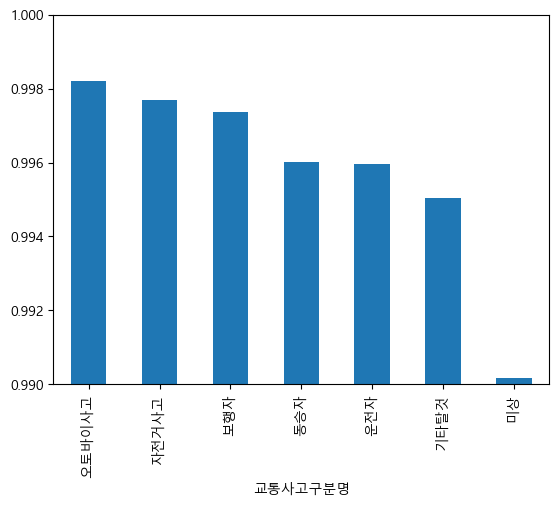

In [12]:
df_tr['중증외상_여부'] = df_tr['중증외상명'].notna().astype(int)
# np.where(df_tr['중증외상명'] == 'Y', 1, 0)
# df_tr.groupby('교통사고구분명')['중증외상_여부'].mean()
result = df_tr.groupby('교통사고구분명')['중증외상_여부'].agg(전체건수='size', 중증외상건수='sum')

# pd.DataFrame({'전체건수':df_tr.groupby('교통사고구분명')['중증외상_여부'].size(),
#               '중증외상건수':df_tr.groupby('교통사고구분명')['중증외상_여부'].sum()})

result['중증외상비율'] = result['중증외상건수'] / result['전체건수']

result['중증외상비율'].sort_values(ascending=False).plot.bar()
plt.ylim([0.990,1])
plt.show()

In [13]:
resc[['신고일자','신고시각','신고연도','신고월','신고일','신고시간','신고분','신고요일']].head()

,신고일자,신고시각,신고연도,신고월,신고일,신고시간,신고분,신고요일
0,20230109,90100,2023,1,9,9,1,월요일
1,20230109,90100,2023,1,9,9,1,월요일
2,20230109,90100,2023,1,9,9,1,월요일
3,20230109,90100,2023,1,9,9,1,월요일
4,20230109,90100,2023,1,9,9,1,월요일


In [14]:
import pandas as pd
# 1. 신고일자(8자리)와 신고시각(앞에 0을 채워 6자리로 만든 문자열)을 결합 
datetime_str = resc['신고일자'].astype(str) + resc['신고시각'].astype(str).str.zfill(6) 
datetime_str

0          20230109090100
1          20230109090100
2          20230109090100
3          20230109090100
4          20230109090100
                ...      
3536890    20231226130000
3536891    20231226130000
3536892    20231229095000
3536893    20231224144500
3536894    20231227012700
Length: 3536895, dtype: object

In [15]:
# 2. 지정된 포맷(%Y%m%d%H%M%S)에 맞추어 datetime으로 변환
resc['신고일시'] = pd.to_datetime(datetime_str, format='%Y%m%d%H%M%S')
resc['신고일시']

0         2023-01-09 09:01:00
1         2023-01-09 09:01:00
2         2023-01-09 09:01:00
3         2023-01-09 09:01:00
4         2023-01-09 09:01:00
                  ...        
3536890   2023-12-26 13:00:00
3536891   2023-12-26 13:00:00
3536892   2023-12-29 09:50:00
3536893   2023-12-24 14:45:00
3536894   2023-12-27 01:27:00
Name: 신고일시, Length: 3536895, dtype: datetime64[ns]

<Axes: xlabel='신고월'>

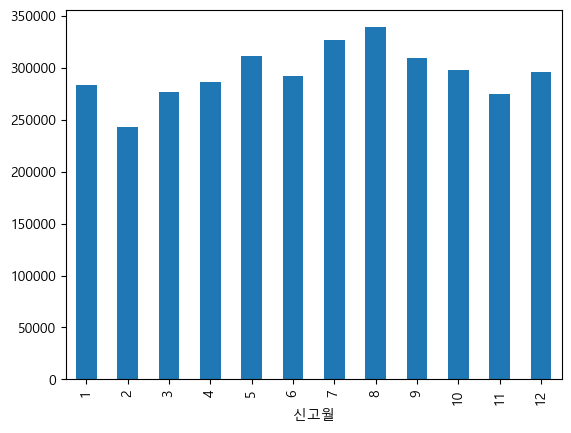

In [16]:
resc.groupby(['신고월']).size().plot.bar()

<Axes: xlabel='신고월'>

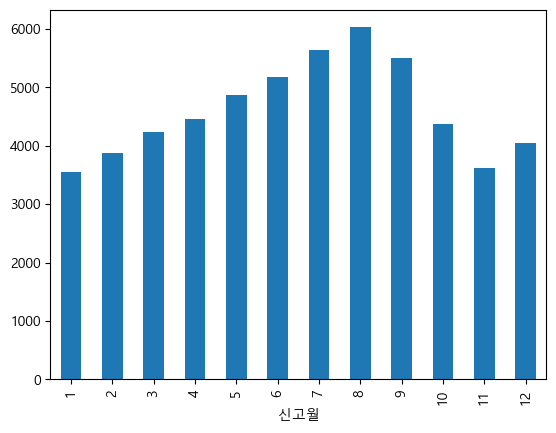

In [17]:
# 월별로 -> groupby
# (기타발생유형명) 단순 주취, 개수
df = resc[['신고월', '기타발생유형명']]
df = df[df['기타발생유형명'] == '단순주취']
df.groupby('신고월').size().plot.bar()

In [18]:
# 계절별 상위 다섯개 질병
def func(df): return df.value_counts()[:5]

# 개별 그룹별로 df이 만들어진다.
# 개별 df에 대한 처리(map)
resc.groupby('계절명')['환자증상구분명'].apply(func)

계절명      
가을   기타통증    113365
     복통       59903
     기타       58373
     요통       33265
     두통       32411
겨울   기타통증     98871
     복통       58699
     기타       54643
     요통       30465
     두통       29733
봄    기타통증    108665
     기타       59622
     복통       59577
     어지러움     32403
     요통       32205
여름   기타통증    115653
     기타       67106
     복통       64433
     고열       39905
     어지러움     37376
Name: 환자증상구분명, dtype: int64

<Axes: xlabel='신고월'>

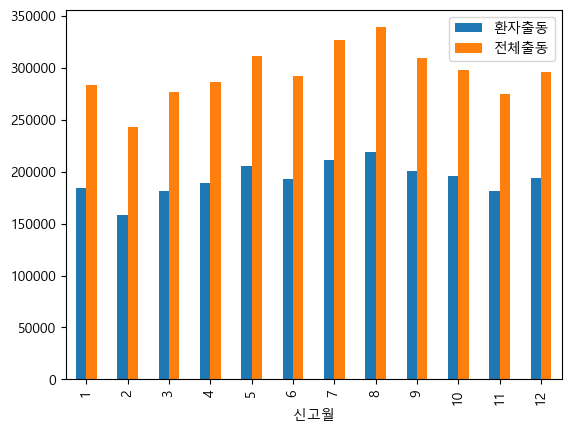

In [21]:
a = resc[resc['환자증상구분명'].notna()].groupby('신고월').size()
b = resc.groupby('신고월').size()
pd.DataFrame({'환자출동':a, '전체출동':b}).plot.bar()